# PARTICIPANT 2

This script processes environmental monitoring data collected from various sources including Eltek, bathroom sensors, bedroom CO2 sensors, weather data, and noise sensors. The script cleans, merges, and calibrates this data to create a consolidated dataset. Additionally, it identifies and handles issues in the data (e.g., sensor errors) and prepares the data for further analysis.

**Key features:**
- Ingest and preprocess environmental data from multiple sources.
- Calibrate and baseline CO2 and noise data.
- Handle missing, infinite, and erroneous data points.
- Generate dictionaries categorizing data by room and type for analysis.

**Notes about campaign:**
1. Change over battery on 05/03/2021
2. Returned initial equipment 12/03/2021. Returned EI130832 - from kitchen window - turned blank after a few weeks and replaced.
3. Started measuring noise at rear towards end of Feb '21

**Notes about data/analysis:**
1. 210312 EI130832 - problem with this sensor
2. 220408 EI130825 - problem with this sensor
3. 14 event sensors - 2 didnt work

## Import Packages and Functions

In [1]:
# -*- coding: utf-8 -*-
#!/usr/bin/python

import os

# run shared function notebooks to load all functions
%run functions.ipynb
%run plotting_functions.ipynb

Packages loaded.

All functions have been defined.


## Load Eltek Data

Load environmental data from the Eltek AQ110a sensor system for living room, kitchen, external, and bedroom measurements.

Sensor IDs: 32657, 30819, 32670, 36245, 36246

In [2]:
p2_eltek = ingest_aq110a(path = '../data/p2_oxford_semi/data_unprocessed/K01817-12158.csv'
                      , import_variables = ['','temperature', 'humidity', 'co2', '1um', '25um', '100um', 'airflow', 'no2', 'co1', 'voc'
                                            , 'temperature', 'humidity', 'co2', '1um', '25um', '100um', 'airflow', 'no2', 'co1', 'voc'
                                            , 'temperature', 'humidity', 'co2', '1um', '25um', '100um', 'airflow', 'no2', 'co1', 'voc'
                                            ,'temperature', 'humidity', 'co2'
                                            ,'temperature', 'humidity', 'co2'
                                            ]
                      , column_names = ['living_temperature', 'living_humidity', 'living_co2', 'living_1um', 'living_25um', 'living_100um', 'living_airflow', 'living_no2', 'living_co1', 'living_voc',
                                        'kitchen_temperature', 'kitchen_humidity', 'kitchen_co2', 'kitchen_1um', 'kitchen_25um', 'kitchen_100um', 'kitchen_airflow', 'kitchen_no2', 'kitchen_co1', 'kitchen_voc',
                                        'external_temperature', 'external_humidity', 'external_co2', 'external_1um', 'external_25um', 'external_100um', 'external_airflow', 'external_no2', 'external_co1', 'external_voc',
                                        'bedroom2_temperature', 'bedroom2_humidity', 'bedroom2_co2',
                                        'bedroom1_temperature', 'bedroom1_humidity', 'bedroom1_co2'
                                        ]
                      , convert_no2 = True
                      , convert_co = True
                      , input_interpolate = True
                      , input_iterpolate_limit = 6
                      )

# sorting out nan in voc's - change nan to 0
p2_eltek['living_voc'] = p2_eltek['living_voc'].fillna(0)
p2_eltek['kitchen_voc'] = p2_eltek['kitchen_voc'].fillna(0)
p2_eltek['external_voc'] = p2_eltek['external_voc'].fillna(0)
p2_eltek = p2_eltek.reset_index()
# delete external temp and rh
del p2_eltek['external_temperature']
del p2_eltek['external_humidity']
# baseline co1 and no2
aq110a_no2_co1_baseline (input_dataframe = p2_eltek
                             , input_percentile = 5)


---------------------------------------------
Ingesting AQ110a data from ../data/p2_oxford_semi/data_unprocessed/K01817-12158.csv


/var/folders/6m/c2f6bq0j2fbclrsw82pn99380000gn/T/ipykernel_94267/1228987109.py:59: DtypeWarning: Columns (1,2,3,4,5,6,7,8,9,11,12,13,14,15,16,17,18,19,21,22,23,24,25,26,27,28,29,31,32,33,34,35,36) have mixed types. Specify dtype option on import or set low_memory=False.
  eltek = pd.read_csv(path, skiprows = 3) # ingest



Correction

-----------------------
32657_temperature
baseline_correction

False
<class 'float'>
0.0
slope

False
<class 'float'>
1.0
intercept

False
<class 'float'>
0.0
-----------------------
32657_humidity
baseline_correction

False
<class 'float'>
0.0
slope

False
<class 'float'>
1.0
intercept

False
<class 'float'>
0.0
-----------------------
32657_co2
baseline_correction

False
<class 'float'>
0.0
slope

False
<class 'float'>
1.0
intercept

False
<class 'float'>
0.0
-----------------------
32657_1um
baseline_correction

False
<class 'float'>
0.0
slope

False
<class 'float'>
1.0
intercept

False
<class 'float'>
0.0
-----------------------
32657_25um
baseline_correction

False
<class 'float'>
0.0
slope

False
<class 'float'>
1.0
intercept

False
<class 'float'>
0.0
-----------------------
32657_100um
baseline_correction

False
<class 'float'>
0.0
slope

False
<class 'float'>
1.0
intercept

False
<class 'float'>
0.0
-----------------------
32657_airflow
baseline_correction

False


## Load Bathroom Data

Load bathroom temperature, humidity, and light data from multiple U12-012 sensors across the monitoring period.

In [3]:
#### bathroom - file 1
p2_bathroom_ieq_1 = ingest_u12_012('../data/p2_oxford_semi/data_unprocessed/210312_EI130297.csv'
                      , 0
                      , ['date', 'time', 'bathroom_temperature', 'bathroom_humidity', 'bathroom_light']
                      , '5min'
                      , True
                      , index_as_date = True
                      ,  instrument_ref = 'EI130297'
                      )

#### bathroom - file 2
p2_bathroom_ieq_2 = ingest_u12_012('../data/p2_oxford_semi/data_unprocessed/210531_EI130488.csv'
                      , 0
                      , ['date', 'time', 'bathroom_temperature', 'bathroom_humidity', 'bathroom_light']
                      , '5min'
                      , True
                      , index_as_date = True
                      ,  instrument_ref = 'EI130488'
                      )

#### bathroom - file 3
p2_bathroom_ieq_3 = ingest_u12_012('../data/p2_oxford_semi/data_unprocessed/210824_EI130565.csv'
                      , 0
                      , ['date', 'time', 'bathroom_temperature', 'bathroom_humidity', 'bathroom_light']
                      , '5min'
                      , True
                      , index_as_date = True
                      ,  instrument_ref = 'EI130565'
                      )

#### bathroom - file 4
p2_bathroom_ieq_4 = ingest_u12_012('../data/p2_oxford_semi/data_unprocessed/211121_EI130556.csv'
                      , 0
                      , ['date', 'time', 'bathroom_temperature', 'bathroom_humidity', 'bathroom_light']
                      , '5min'
                      , True
                      , index_as_date = True
                      ,  instrument_ref = 'EI130556'
                      )

#### bathroom - file 5
p2_bathroom_ieq_5 = ingest_u12_012('../data/p2_oxford_semi/data_unprocessed/220213_EI130264.csv'
                      , 0
                      , ['date', 'time', 'bathroom_temperature', 'bathroom_humidity', 'bathroom_light']
                      , '5min'
                      , True
                      , index_as_date = True
                      ,  instrument_ref = 'EI130264'
                      )

#### bathroom - file 6
p2_bathroom_ieq_6 = ingest_u12_012('../data/p2_oxford_semi/data_unprocessed/220408_EI130469.csv'
                      , 0
                      , ['date', 'time', 'bathroom_temperature', 'bathroom_humidity', 'bathroom_light']
                      , '5min'
                      , True
                      , index_as_date = True
                      ,  instrument_ref = 'EI130469'
                      )


---------------------------------------------
Ingesting U12-012 data from ../data/p2_oxford_semi/data_unprocessed/210312_EI130297.csv
baseline_correction

False
<class 'float'>
0.0
slope

False
<class 'float'>
1.0
intercept

False
<class 'float'>
0.0
baseline_correction

False
<class 'float'>
0.0
slope

False
<class 'float'>
1.0
intercept

False
<class 'float'>
0.0
Missing data = 
 bathroom_temperature    0
bathroom_humidity       0
bathroom_light          0
dtype: int64
U12-012 data ingested
---------------------------------------------


---------------------------------------------
Ingesting U12-012 data from ../data/p2_oxford_semi/data_unprocessed/210531_EI130488.csv
baseline_correction

False
<class 'float'>
0.0
slope

False
<class 'float'>
1.0
intercept

False
<class 'float'>
0.0
baseline_correction

False
<class 'float'>
0.0
slope

False
<class 'float'>
1.0
intercept

False
<class 'float'>
0.0
Missing data = 
 bathroom_temperature    0
bathroom_humidity       0
bathroom_light  

## Join Bathroom Data

Concatenate bathroom data from different time periods:
- File 1: beginning to 2021-03-01 12:00
- File 2: 2021-03-01 12:05 to 2021-05-27 12:00
- File 3: 2021-05-27 12:05 to 2021-08-22 12:00
- File 4: 2021-08-22 12:05 to 2021-11-18 12:00
- File 5: 2021-11-18 12:05 to 2022-02-05 00:00
- File 6: 2022-02-05 00:05 to end

In [4]:
#### join all bathroom 1
p2_bathroom_ieq_1 = p2_bathroom_ieq_1.loc[:'2021-03-01 12:00:00']
p2_bathroom_ieq_2 = p2_bathroom_ieq_2.loc['2021-03-01 12:05:00':'2021-05-27 12:00:00']
p2_bathroom_ieq_3 = p2_bathroom_ieq_3.loc['2021-05-27 12:05:00':'2021-08-22 12:00:00']
p2_bathroom_ieq_4 = p2_bathroom_ieq_4.loc['2021-08-22 12:05:00':'2021-11-18 12:00:00']
p2_bathroom_ieq_5 = p2_bathroom_ieq_5.loc['2021-11-18 12:05:00':'2022-02-05 00:00:00']
p2_bathroom_ieq_6 = p2_bathroom_ieq_6.loc['2022-02-05 00:05:00':]
p2_dfs = [p2_bathroom_ieq_1, p2_bathroom_ieq_2, p2_bathroom_ieq_3, p2_bathroom_ieq_4, p2_bathroom_ieq_5, p2_bathroom_ieq_6]
p2_bathroom = pd.concat(p2_dfs)
p2_bathroom = p2_bathroom.resample('5T').ffill() # resample and backfill for 5 mins
del p2_bathroom_ieq_1, p2_bathroom_ieq_2, p2_bathroom_ieq_3, p2_bathroom_ieq_4, p2_bathroom_ieq_5, p2_bathroom_ieq_6
del p2_dfs
p2_bathroom = p2_bathroom.copy()

/var/folders/6m/c2f6bq0j2fbclrsw82pn99380000gn/T/ipykernel_94267/3911944249.py:10: FutureWarning: 'T' is deprecated and will be removed in a future version, please use 'min' instead.
  p2_bathroom = p2_bathroom.resample('5T').ffill() # resample and backfill for 5 mins


## Load Bedroom 3 Data

Load bedroom 3 temperature, humidity, and CO2 data from multiple MX1102 sensors.

In [5]:
p2_bedroom3_ieq_1 = ingest_mx1102("../data/p2_oxford_semi/data_unprocessed/210312_EI130715.csv"
                     , 1
                     , ['date', 'time', 'bedroom3_temperature', 'bedroom3_humidity', 'bedroom3_co2']
                     , '5min'
                     , True
                     ,  instrument_ref = 'EI130715'
                     , index_as_date = True
                     )

p2_bedroom3_ieq_2 = ingest_mx1102("../data/p2_oxford_semi/data_unprocessed/210531_EI130708.csv"
                     , 1
                     , ['date', 'time', 'bedroom3_temperature', 'bedroom3_humidity', 'bedroom3_co2']
                     , '5min'
                     , True
                     ,  instrument_ref = 'EI130708'
                     , index_as_date = True
                     )

p2_bedroom3_ieq_3 = ingest_mx1102("../data/p2_oxford_semi/data_unprocessed/210824_EI130716.csv"
                     , 1
                     , ['date', 'time', 'bedroom3_temperature', 'bedroom3_humidity', 'bedroom3_co2']
                     , '5min'
                     , True
                     ,  instrument_ref = 'EI130716'
                     , index_as_date = True
                     )

p2_bedroom3_ieq_4 = ingest_mx1102("../data/p2_oxford_semi/data_unprocessed/211121_EI130720.csv"
                     , 1
                     , ['date', 'time', 'bedroom3_temperature', 'bedroom3_humidity', 'bedroom3_co2']
                     , '5min'
                     , True
                     ,  instrument_ref = 'EI130720'
                     , index_as_date = True
                     )

p2_bedroom3_ieq_5 = ingest_mx1102("../data/p2_oxford_semi/data_unprocessed/220213_EI130723.csv"
                     , 1
                     , ['date', 'time', 'bedroom3_temperature', 'bedroom3_humidity', 'bedroom3_co2']
                     , '5min'
                     , True
                     ,  instrument_ref = 'EI130723'
                     , index_as_date = True
                     )

p2_bedroom3_ieq_6 = ingest_mx1102("../data/p2_oxford_semi/data_unprocessed/220408_EI130715.csv"
                     , 1
                     , ['date', 'time', 'bedroom3_temperature', 'bedroom3_humidity', 'bedroom3_co2']
                     , '5min'
                     , True
                     ,  instrument_ref = 'EI130715'
                     , index_as_date = True
                     )


---------------------------------------------
Ingesting MX1102 data from ../data/p2_oxford_semi/data_unprocessed/210312_EI130715.csv
baseline_correction

False
<class 'float'>
0.0
slope

False
<class 'float'>
1.0
intercept

False
<class 'float'>
0.0
baseline_correction

False
<class 'float'>
0.0
slope

False
<class 'float'>
1.0
intercept

False
<class 'float'>
0.0
baseline_correction

False
<class 'float'>
0.0
slope

False
<class 'float'>
1.0
intercept

False
<class 'float'>
0.0
Missing data = 
 bedroom3_temperature    0
bedroom3_humidity       0
bedroom3_co2            0
dtype: int64
MX1102 data ingested
---------------------------------------------


---------------------------------------------
Ingesting MX1102 data from ../data/p2_oxford_semi/data_unprocessed/210531_EI130708.csv
baseline_correction

False
<class 'float'>
0.0
slope

False
<class 'float'>
1.0
intercept

False
<class 'float'>
0.0
baseline_correction

False
<class 'float'>
0.0
slope

False
<class 'float'>
1.0
intercep

## Join Bedroom 3 Data

Concatenate bedroom 3 data from different time periods.

In [6]:
#### join all bedroom 3
p2_bedroom3_ieq_1 = p2_bedroom3_ieq_1.loc[:'2021-03-05 12:00:00']
p2_bedroom3_ieq_2 = p2_bedroom3_ieq_2.loc['2021-03-05 12:05:00':'2021-05-25 12:00:00']
p2_bedroom3_ieq_3 = p2_bedroom3_ieq_3.loc['2021-05-25 12:05:00':]
p2_bedroom3_ieq_4 = p2_bedroom3_ieq_4.loc[:'2021-11-16 12:00:00']
p2_bedroom3_ieq_5 = p2_bedroom3_ieq_5.loc['2021-11-16 12:05:00':'2022-02-05 12:00:00']
p2_bedroom3_ieq_6 = p2_bedroom3_ieq_6.loc['2022-02-05 12:05:00':]
p2_dfs = [p2_bedroom3_ieq_1, p2_bedroom3_ieq_2, p2_bedroom3_ieq_3, p2_bedroom3_ieq_4, p2_bedroom3_ieq_5, p2_bedroom3_ieq_6]
p2_bedroom3 = pd.concat(p2_dfs)
p2_bedroom3 = p2_bedroom3.resample('5T').ffill() # resample and backfill for 5 mins
del p2_bedroom3_ieq_1, p2_bedroom3_ieq_2, p2_bedroom3_ieq_3, p2_bedroom3_ieq_4, p2_bedroom3_ieq_5, p2_bedroom3_ieq_6
del p2_dfs
p2_bedroom3 = p2_bedroom3.copy()

/var/folders/6m/c2f6bq0j2fbclrsw82pn99380000gn/T/ipykernel_94267/783269362.py:10: FutureWarning: 'T' is deprecated and will be removed in a future version, please use 'min' instead.
  p2_bedroom3 = p2_bedroom3.resample('5T').ffill() # resample and backfill for 5 mins


## Load Dining Room Data

Load dining room temperature, humidity, and CO2 data from multiple MX1102 sensors.

In [7]:
p2_dining_ieq_1 = ingest_mx1102("../data/p2_oxford_semi/data_unprocessed/210312_EI130716.csv"
                     , 1
                     , ['date', 'time', 'dining_temperature', 'dining_humidity', 'dining_co2']
                     , '5min'
                     , True
                     ,  instrument_ref = 'EI130716'
                     , index_as_date = True
                     )

p2_dining_ieq_2 = ingest_mx1102("../data/p2_oxford_semi/data_unprocessed/210531_EI130710.csv"
                     , 1
                     , ['date', 'time', 'dining_temperature', 'dining_humidity', 'dining_co2']
                     , '5min'
                     , True
                     ,  instrument_ref = 'EI130710'
                     , index_as_date = True
                     )

p2_dining_ieq_3 = ingest_mx1102("../data/p2_oxford_semi/data_unprocessed/210824_EI130715.csv"
                     , 1
                     , ['date', 'time', 'dining_temperature', 'dining_humidity', 'dining_co2']
                     , '5min'
                     , True
                     ,  instrument_ref = 'EI130715'
                     , index_as_date = True
                     )

p2_dining_ieq_4 = ingest_mx1102("../data/p2_oxford_semi/data_unprocessed/211121_EI130710.csv"
                     , 1
                     , ['date', 'time', 'dining_temperature', 'dining_humidity', 'dining_co2']
                     , '5min'
                     , True
                     ,  instrument_ref = 'EI130710'
                     , index_as_date = True
                     )

p2_dining_ieq_5 = ingest_mx1102("../data/p2_oxford_semi/data_unprocessed/220213_EI130708.csv"
                     , 1
                     , ['date', 'time', 'dining_temperature', 'dining_humidity', 'dining_co2']
                     , '5min'
                     , True
                     ,  instrument_ref = 'EI130708'
                     , index_as_date = True
                     )

p2_dining_ieq_6 = ingest_mx1102("../data/p2_oxford_semi/data_unprocessed/220408_EI130719.csv"
                     , 1
                     , ['date', 'time', 'dining_temperature', 'dining_humidity', 'dining_co2']
                     , '5min'
                     , True
                     ,  instrument_ref = 'EI130719'
                     , index_as_date = True
                     )


---------------------------------------------
Ingesting MX1102 data from ../data/p2_oxford_semi/data_unprocessed/210312_EI130716.csv
baseline_correction

False
<class 'float'>
0.0
slope

False
<class 'float'>
1.0
intercept

False
<class 'float'>
0.0
baseline_correction

False
<class 'float'>
0.0
slope

False
<class 'float'>
1.0
intercept

False
<class 'float'>
0.0
baseline_correction

False
<class 'float'>
0.0
slope

False
<class 'float'>
1.0
intercept

False
<class 'float'>
0.0
Missing data = 
 dining_temperature    0
dining_humidity       0
dining_co2            0
dtype: int64
MX1102 data ingested
---------------------------------------------


---------------------------------------------
Ingesting MX1102 data from ../data/p2_oxford_semi/data_unprocessed/210531_EI130710.csv
baseline_correction

False
<class 'float'>
0.0
slope

False
<class 'float'>
1.0
intercept

False
<class 'float'>
0.0
baseline_correction

False
<class 'float'>
0.0
slope

False
<class 'float'>
1.0
intercept

Fal

## Join Dining Room Data

Concatenate dining room data from different time periods.

In [8]:
#### join all dining
p2_dining_ieq_1 = p2_dining_ieq_1.loc[:'2021-03-05 12:00:00']
p2_dining_ieq_2 = p2_dining_ieq_2.loc['2021-03-05 12:05:00':'2021-05-25 12:00:00']
p2_dining_ieq_3 = p2_dining_ieq_3.loc['2021-05-25 12:05:00':]
p2_dining_ieq_4 = p2_dining_ieq_4.loc[:'2021-11-16 14:00:00']
p2_dining_ieq_5 = p2_dining_ieq_5.loc['2021-11-16 14:05:00':'2022-02-05 12:00:00']
p2_dining_ieq_6 = p2_dining_ieq_6.loc['2022-02-05 12:05:00':]
p2_dfs = [p2_dining_ieq_1, p2_dining_ieq_2, p2_dining_ieq_3, p2_dining_ieq_4, p2_dining_ieq_5, p2_dining_ieq_6]
p2_dining = pd.concat(p2_dfs)
p2_dining = p2_dining.resample('5min').ffill() # resample and backfill for 5 mins
del p2_dining_ieq_1, p2_dining_ieq_2, p2_dining_ieq_3, p2_dining_ieq_4, p2_dining_ieq_5, p2_dining_ieq_6
del p2_dfs
# del loop_df
p2_dining = p2_dining.copy()

## Merge Eltek, Bedroom3, Bathroom and Dining Data

In [9]:

p2_dfs = [p2_eltek, p2_bedroom3, p2_bathroom, p2_dining] # create a list with all p2_dfs to be merged
p2 = reduce(lambda left,right: pd.merge(left,right,on='date', how='outer'), p2_dfs) # merge
p2 = p2.sort_index() # sort by index
#### clean-up
del p2_dfs, p2_eltek, p2_bedroom3, p2_bathroom, p2_dining
p2.isna().sum() #should equal 0
p2.duplicated()
p2 = p2.sort_values(by=['date'])
p2 = p2.reset_index(drop=True)
# set date as index
p2 = p2.set_index(p2['date'])
# delete date
del p2['date']

## Filter DataFrame Based on Campaign Dates

In [10]:

monitoring_start_date = '2021-01-18 18:00:00'
monitoring_end_date = '2022-04-07 23:55:00'
p2 = p2.loc[monitoring_start_date : monitoring_end_date]

## Get CO2 Column List

In [11]:
p2_co2_col_list = co2_col_list(p2)

## CO2 Calibration of All CO2 Loggers

Calibrate indoor CO2 sensors using outdoor reference values during unoccupied periods.

In [12]:


co2_correction_unoccupied(input_dataframe = p2
                          , input_start_and_end_as_df = True
                          , input_start_date = ''
                          , input_end_date = ''
                          , input_list_unoccupied_periods = ['2021-01-30 18:00:00', '2021-01-31 16:00:00',
                                                             '2021-04-02 18:00:00', '2021-04-04 00:00:00',
                                                             '2021-04-24 16:00:00', '2021-04-25 12:00:00',
                                                             '2021-05-12 12:00:00', '2021-05-13 18:00:00',
                                                             '2021-05-17 12:00:00', '2021-05-18 16:00:00',
                                                             '2021-05-20 12:00:00', '2021-05-21 12:00:00',
                                                             '2021-05-31 16:00:00', '2021-06-01 16:00:00',
                                                             '2021-06-18 21:00:00', '2021-06-19 18:00:00',
                                                             '2021-07-11 12:00:00', '2021-07-17 12:00:00',
                                                             '2021-07-23 12:00:00', '2021-07-24 06:00:00',
                                                             '2021-09-01 12:00:00', '2021-09-03 12:00:00',
                                                             '2021-09-09 12:00:00', '2021-09-10 08:00:00',
                                                             '2021-10-08 18:00:00', '2021-10-10 18:00:00',
                                                             '2021-10-23 00:00:00', '2021-10-25 12:00:00',
                                                             '2021-11-06 12:00:00', '2021-11-06 18:00:00',
                                                             '2021-11-11 12:00:00', '2021-11-11 18:00:00',
                                                             '2021-11-27 15:00:00', '2021-11-28 15:00:00',
                                                             '2021-12-11 00:00:00', '2021-12-12 18:00:00',
                                                             '2022-01-28 00:00:00', '2022-01-31 12:00:00',
                                                             '2022-02-19 12:00:00', '2022-02-20 15:00:00',
                                                             '2022-03-10 12:00:00', '2022-03-11 12:00:00',
                                                             '2022-04-03 16:00:00', '2022-04-04 16:00:00']
                          , input_outdoor_co2_col = 'external_co2'
                          , input_co2_cols_to_correct = ['living_co2',
                                                        'kitchen_co2',
                                                        'bedroom1_co2',
                                                        'bedroom2_co2',
                                                        'bedroom3_co2',
                                                        'dining_co2']
                          , input_percentile_indoor = 10
                          , input_percentile_outdoor = 50
                          )


====    Start of CO2 correction    ====


Using beginning and end dates from input df
Start date =  2021-01-18 18:00:00
End date =  2022-04-07 23:55:00

-------------------------------------------------------------
----     Correcting:  living_co2     ----
-------------------------------------------------------------

Loop 1
Start of unoccupied period 1 = 2021-01-30 18:00:00
End of unoccupied period 1 = 2021-01-31 16:00:00
Mid point = 2021-01-31 05:00:00
Indoor CO2 10 th percentile is  440.0
Outdoor CO2 50 th percentile is  438.0
Difference in CO2 10 th percentiles is  2.0

Loop 2
Start of unoccupied period 2 = 2021-04-02 18:00:00
End of unoccupied period 2 = 2021-04-04 00:00:00
Mid point = 2021-04-03 09:00:00
Length between previous mid and this mid 17905
Indoor CO2 10 th percentile is  438.0
Outdoor CO2 50 th percentile is  447.0
Difference in CO2 10 th percentiles is  -9.0
Offset difference =  -11.0
Slope =  -0.0006143535325328121

Loop 3
Start of unoccupied period 3 = 2021-04-24 1

## Import Event Data

Load window and door event data from UX90-001M sensors.

**Not used:** EI130811, EI130813, EI130833, EI130841, EI130825 (closed whole time), EI130832 (failed sensor)

**Used:** EI130804, EI130827, EI130798, EI130836, EI130821, EI130835, EI130830, EI130796, EI130826, EI130793, EI130818

In [13]:

p2_event_dict = ingest_ux90_001m_group_new(input_file_list =
                           ['../data/p2_oxford_semi/data_unprocessed/220408_EI130804.csv',
                           '../data/p2_oxford_semi/data_unprocessed/220408_EI130827.csv',
                           '../data/p2_oxford_semi/data_unprocessed/220408_EI130798.csv',
                           '../data/p2_oxford_semi/data_unprocessed/220408_EI130836.csv',
                           '../data/p2_oxford_semi/data_unprocessed/220408_EI130821.csv',
                           '../data/p2_oxford_semi/data_unprocessed/220408_EI130835.csv',
                           '../data/p2_oxford_semi/data_unprocessed/220408_EI130830.csv',
                           '../data/p2_oxford_semi/data_unprocessed/220408_EI130796.csv',
                           '../data/p2_oxford_semi/data_unprocessed/220408_EI130826.csv',
                           '../data/p2_oxford_semi/data_unprocessed/220408_EI130793.csv',
                           '../data/p2_oxford_semi/data_unprocessed/220408_EI130818.csv'
                           ]
                       , input_output_name_list =
                           [
                           'bathroom_window_event',
                           'kitchen_window_event',
                           'bedroom1_window_event',
                           'main_door_event',
                           'gf_hall_window_event',
                           'ff_hall_window_event',
                           'bedroom3_window_event',
                           'bedroom2_window_event',
                           'kitchen_sliding_door_event',
                           'kitchen_back_door_event',
                           'living_window_event'
                            ]
                       , input_skiprows = 0
                       , input_main_dataframe = p2
                       )

event_durations(input_event_dict = p2_event_dict)
p2_event_dict['main_door_event'] = p2_event_dict['main_door_event'].set_index(p2_event_dict['main_door_event']['date'])
#### list of all events
p2_event_list = event_list_function(input_event_dict = p2_event_dict)


---------------------------------------------
Ingesting ux90_001m data from ../data/p2_oxford_semi/data_unprocessed/220408_EI130804.csv

---------------------------------------------
Ingesting ux90_001m data from ../data/p2_oxford_semi/data_unprocessed/220408_EI130827.csv

---------------------------------------------
Ingesting ux90_001m data from ../data/p2_oxford_semi/data_unprocessed/220408_EI130798.csv

---------------------------------------------
Ingesting ux90_001m data from ../data/p2_oxford_semi/data_unprocessed/220408_EI130836.csv

---------------------------------------------
Ingesting ux90_001m data from ../data/p2_oxford_semi/data_unprocessed/220408_EI130821.csv

---------------------------------------------
Ingesting ux90_001m data from ../data/p2_oxford_semi/data_unprocessed/220408_EI130835.csv

---------------------------------------------
Ingesting ux90_001m data from ../data/p2_oxford_semi/data_unprocessed/220408_EI130830.csv

----------------------------------------

## Import Weather Data

Load external weather data from CEDA.

In [14]:
p2_weather = ingest_ceda_weather_data(input_path = '../data/p2_oxford_semi/data_unprocessed/weather.csv'
                         , skiprows = 0
                         , cols_from_ceda = ['ob_time', ' wind_direction', ' wind_speed', ' air_temperature', ' dewpoint', ' wetb_temp', ' rltv_hum']
                         , new_col_names = ['date', 'external_wind_direction', 'external_wind_speed', 'external_temperature', 'external_dewpoint', 'external_wetb_temp', 'external_humidity']
                         )


---------------------------------------------
Ingesting weather data from ../data/p2_oxford_semi/data_unprocessed/weather.csv
nans before interpolating =  external_wind_direction    6
external_wind_speed        6
external_temperature       6
external_dewpoint          6
external_wetb_temp         6
external_humidity          6
dtype: int64
nans before interpolating =  external_wind_direction    0
external_wind_speed        0
external_temperature       0
external_dewpoint          0
external_wetb_temp         0
external_humidity          0
dtype: int64
Weather data ingested


## Merge Weather Data

In [15]:


# create a list with all p2_dfs to be merged
p2_dfs = [p2, p2_weather]
# merge
p2 = reduce(lambda left,right: pd.merge(left,right,on='date', how='outer'), p2_dfs)
# sort by index
p2 = p2.sort_index()
#### clean-up
del p2_dfs, p2_weather
p2.isna().sum() #should equal 0
p2.duplicated()
p2 = p2.sort_values(by=['date'])
p2 = p2.reset_index(drop=False)
# set date as index
p2 = p2.set_index(p2['date'])
# delete date
del p2['date']

## Import Raspberry Pi Noise Data

Load and process noise measurement data from Raspberry Pi microphones.

**Four different units used:**
- PHEUCLio_004 (BF Unit) - replaced 08/05/2021
- PHEUCLio_0010 (BF Unit) - installed 08/05/2021
- PHEUCLio_003 (BF Unit) - replaced 08/05/2021
- PHEUCLio_009 (BF Unit) - installed 08/05/2021

Units 3 and 4 installed from start to 2021-05-08  
Units 9 and 10 installed from 2021-05-08 to end

In [16]:


p2_noise_dict, p2_noise_inside, p2_noise_outside =  rpi_noise_ingest(input_start_directory = '../data/p2_oxford_semi/data_unprocessed/noise/')

####    joining the two noise unit data together
p2_unit3_in = p2_noise_dict['PHEUCLio003', 'in']
p2_unit3_out = p2_noise_dict['PHEUCLio003', 'out']

p2_unit4_in = p2_noise_dict['PHEUCLio004', 'in']
p2_unit4_out = p2_noise_dict['PHEUCLio004', 'out']

p2_unit9_in = p2_noise_dict['PHEUCLio009', 'in']
p2_unit9_out = p2_noise_dict['PHEUCLio009', 'out']

p2_unit10_in = p2_noise_dict['PHEUCLio010', 'in']
p2_unit10_out = p2_noise_dict['PHEUCLio010', 'out']

p2_unit3_in = p2_unit3_in.sort_index()
p2_unit3_in = p2_unit3_in.loc[:'2021-05-08 12:00:00']
p2_unit3_out = p2_unit3_out.sort_index()
p2_unit3_out = p2_unit3_out.loc[:'2021-05-08 12:00:00']

p2_unit4_in = p2_unit4_in.sort_index()
p2_unit4_in = p2_unit4_in.loc[:'2021-05-08 12:00:00']
p2_unit4_out = p2_unit4_out.sort_index()
p2_unit4_out = p2_unit4_out.loc[:'2021-05-08 12:00:00']

p2_unit9_in = p2_unit9_in.sort_index()
p2_unit9_in = p2_unit9_in.loc['2021-05-08 12:05:00':]
p2_unit9_out = p2_unit9_out.sort_index()
p2_unit9_out = p2_unit9_out.loc['2021-05-08 12:05:00':]

p2_unit10_in = p2_unit10_in.sort_index()
p2_unit10_in = p2_unit10_in.loc['2021-05-08 12:05:00':]
p2_unit10_out = p2_unit10_out.sort_index()
p2_unit10_out = p2_unit10_out.loc['2021-05-08 12:05:00':]

## front
# merge 4 and 10 indoor mics
p2_dfs = [p2_unit4_in, p2_unit10_in]
p2_noise_inside_front = pd.concat(p2_dfs)
p2_noise_inside_front = p2_noise_inside_front[~p2_noise_inside_front.index.duplicated(keep='first')]
p2_noise_inside_front = p2_noise_inside_front.resample('5min').ffill() # resample and backfill for 5 mins
# merge 4 and 10 outdoor mics
p2_dfs = [p2_unit4_out, p2_unit10_out]
p2_noise_outside_front = pd.concat(p2_dfs)
p2_noise_outside_front = p2_noise_outside_front[~p2_noise_outside_front.index.duplicated(keep='first')]
p2_noise_outside_front = p2_noise_outside_front.resample('5min').ffill() # resample and backfill for 5 mins

## rear
# merge 3 and 9 indoor mics
p2_dfs = [p2_unit3_in, p2_unit9_in]
p2_noise_inside_rear = pd.concat(p2_dfs)
p2_noise_inside_rear = p2_noise_inside_rear[~p2_noise_inside_rear.index.duplicated(keep='first')]
p2_noise_inside_rear = p2_noise_inside_rear.resample('5min').ffill() # resample and backfill for 5 mins
# merge 3 and 9 outdoor mics
p2_dfs = [p2_unit3_out, p2_unit9_out]
p2_noise_outside_rear = pd.concat(p2_dfs)
p2_noise_outside_rear = p2_noise_outside_rear[~p2_noise_outside_rear.index.duplicated(keep='first')]
p2_noise_outside_rear = p2_noise_outside_rear.resample('5min').ffill() # resample and backfill for 5 mins
del p2_unit10_in, p2_unit10_out, p2_unit3_in, p2_unit3_out, p2_unit4_in, p2_unit4_out, p2_unit9_in, p2_unit9_out
del p2_noise_inside, p2_noise_outside

## Merge Noise Data into Main DataFrame

In [17]:
p2['bedroom3_outside_dba'] = p2_noise_outside_front['laeq']
p2['bedroom3_dba'] = p2_noise_inside_front['laeq']
p2['kitchen_outside_dba'] = p2_noise_outside_rear['laeq']
p2['kitchen_dba'] = p2_noise_inside_rear['laeq']

## Create Room and Variable Dictionary

Generate a dictionary organizing all measured variables by room.

In [18]:
p2_variable_list = ['temperature',
                 'humidity',
                 'co2',
                 '1um',
                 '25um',
                 '100um',
                 'airflow',
                 'no2',
                 'co1',
                 'voc',
                 'light'
                 ]

p2_rooms_and_variables = rooms_variables_dict(input_dataframe = p2
                      ,variables = p2_variable_list)
p2_rooms_and_variables['bedroom3'].remove('outside_dba')
p2_rooms_and_variables['kitchen'].remove('outside_dba')

bedroom3











['temperature', 'humidity', 'co2', 'outside_dba', 'dba']
kitchen











['temperature', 'humidity', 'co2', '1um', '25um', '100um', 'airflow', 'no2', 'co1', 'voc', 'outside_dba', 'dba']
bedroom2











['temperature', 'humidity', 'co2']
bathroom











['temperature', 'humidity', 'light']
living











['temperature', 'humidity', 'co2', '1um', '25um', '100um', 'airflow', 'no2', 'co1', 'voc']
external











['co2', '1um', '25um', '100um', 'airflow', 'no2', 'co1', 'voc', 'wind_direction', 'wind_speed', 'temperature', 'dewpoint', 'wetb_temp', 'humidity']
dining











['temperature', 'humidity', 'co2']
bedroom1











['temperature', 'humidity', 'co2']


## Create Room and Event Dictionary

In [19]:
p2_rooms_list = ['living', 'kitchen', 'bathroom', 'bedroom1', 'bedroom2', 'bedroom3', 'dining']

p2_living_events = ['living_window_event']
p2_kitchen_events = ['kitchen_back_door_event', 'kitchen_window_event', 'kitchen_sliding_door_event']
p2_bathroom_events = ['bathroom_window_event']
p2_bedroom1_events = ['bedroom1_window_event']
p2_bedroom2_events = ['bedroom2_window_event']
p2_bedroom3_events = ['bedroom3_window_event']
p2_dining_events = ['kitchen_back_door_event', 'kitchen_window_event', 'kitchen_sliding_door_event', 'living_window_event']

p2_rooms_and_events = {}
p2_rooms_and_events['living'] = p2_living_events
p2_rooms_and_events['kitchen'] = p2_kitchen_events
p2_rooms_and_events['bathroom'] = p2_bathroom_events
p2_rooms_and_events['bedroom1'] = p2_bedroom1_events
p2_rooms_and_events['bedroom2'] = p2_bedroom2_events
p2_rooms_and_events['bedroom3'] = p2_bedroom3_events
p2_rooms_and_events['dining'] = p2_dining_events

del p2_living_events, p2_kitchen_events, p2_bathroom_events, p2_bedroom1_events, p2_bedroom2_events, p2_bedroom3_events

## Final Data Filtering and Interpolation

Apply final date filters, interpolate missing values, and check for data quality issues.

In [20]:


p2 = p2.loc[monitoring_start_date : monitoring_end_date]
# filter event dict:
for loop_df in p2_event_dict:
    p2_event_dict[loop_df] = p2_event_dict[loop_df][(p2_event_dict[loop_df]['date'] > monitoring_start_date) & (p2_event_dict[loop_df]['date'] < monitoring_end_date)]

# interpolate all variables
for loop_room in p2_rooms_and_variables:
    print('')
    print(loop_room)
    for loop_variable in p2_rooms_and_variables[loop_room]:
        print(loop_room + '_' + loop_variable)
        print('--- Before ---')
        print('NaNs = ', p2[loop_room + '_' + loop_variable].isna().sum()) # count nans
        print('inf = ', len(p2[loop_room + '_' + loop_variable]) - np.isfinite(p2[loop_room + '_' + loop_variable]).sum()) # count all infinite values
        print('--- After ---')
        p2[loop_room + '_' + loop_variable] = p2[loop_room + '_' + loop_variable].interpolate(method='linear', limit = 4, limit_direction='forward')
        print('NaNs = ', p2[loop_room + '_' + loop_variable].isna().sum()) # count nans
        print('inf = ', len(p2[loop_room + '_' + loop_variable]) - np.isfinite(p2[loop_room + '_' + loop_variable]).sum()) # count all infinite


bedroom3
bedroom3_temperature
--- Before ---
NaNs =  0
inf =  0
--- After ---
NaNs =  0
inf =  0
bedroom3_humidity
--- Before ---
NaNs =  0
inf =  0
--- After ---
NaNs =  0
inf =  0
bedroom3_co2
--- Before ---
NaNs =  0
inf =  0
--- After ---
NaNs =  0
inf =  0
bedroom3_dba
--- Before ---
NaNs =  0
inf =  0
--- After ---
NaNs =  0
inf =  0

kitchen
kitchen_temperature
--- Before ---
NaNs =  0
inf =  0
--- After ---
NaNs =  0
inf =  0
kitchen_humidity
--- Before ---
NaNs =  0
inf =  0
--- After ---
NaNs =  0
inf =  0
kitchen_co2
--- Before ---
NaNs =  0
inf =  0
--- After ---
NaNs =  0
inf =  0
kitchen_1um
--- Before ---
NaNs =  0
inf =  0
--- After ---
NaNs =  0
inf =  0
kitchen_25um
--- Before ---
NaNs =  1
inf =  1
--- After ---
NaNs =  0
inf =  0
kitchen_100um
--- Before ---
NaNs =  1
inf =  1
--- After ---
NaNs =  0
inf =  0
kitchen_airflow
--- Before ---
NaNs =  0
inf =  0
--- After ---
NaNs =  0
inf =  0
kitchen_no2
--- Before ---
NaNs =  0
inf =  0
--- After ---
NaNs =  0
inf =

## Plot Results

Generate plots of all grouped variables.

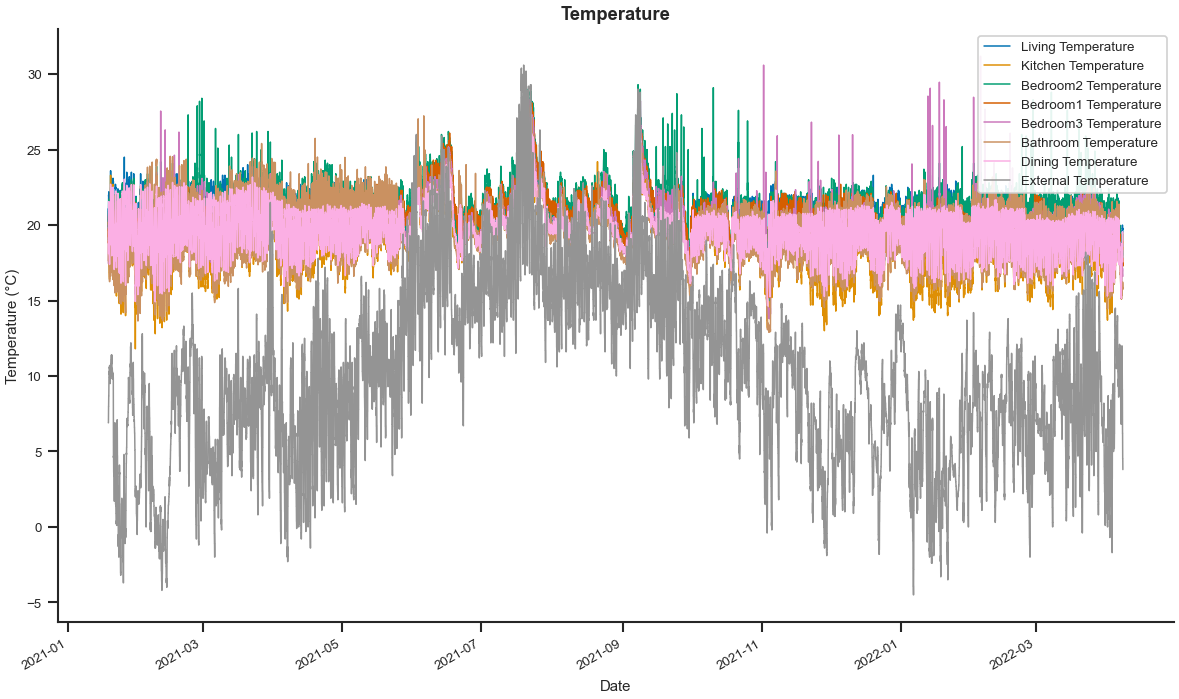

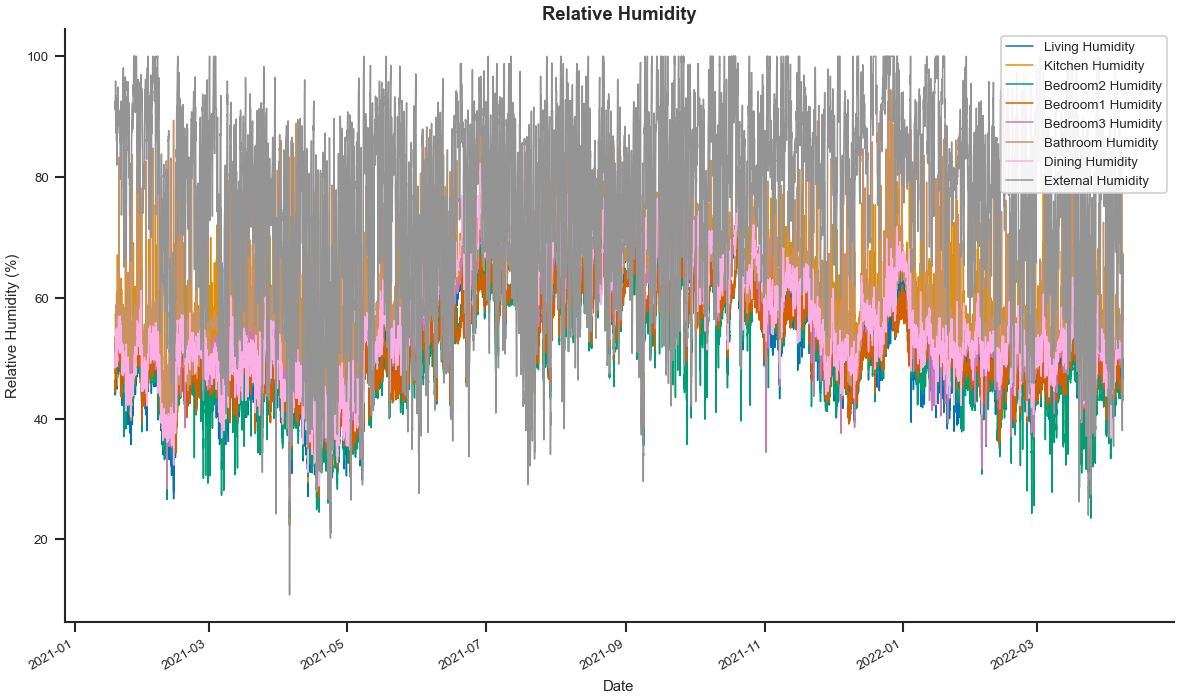

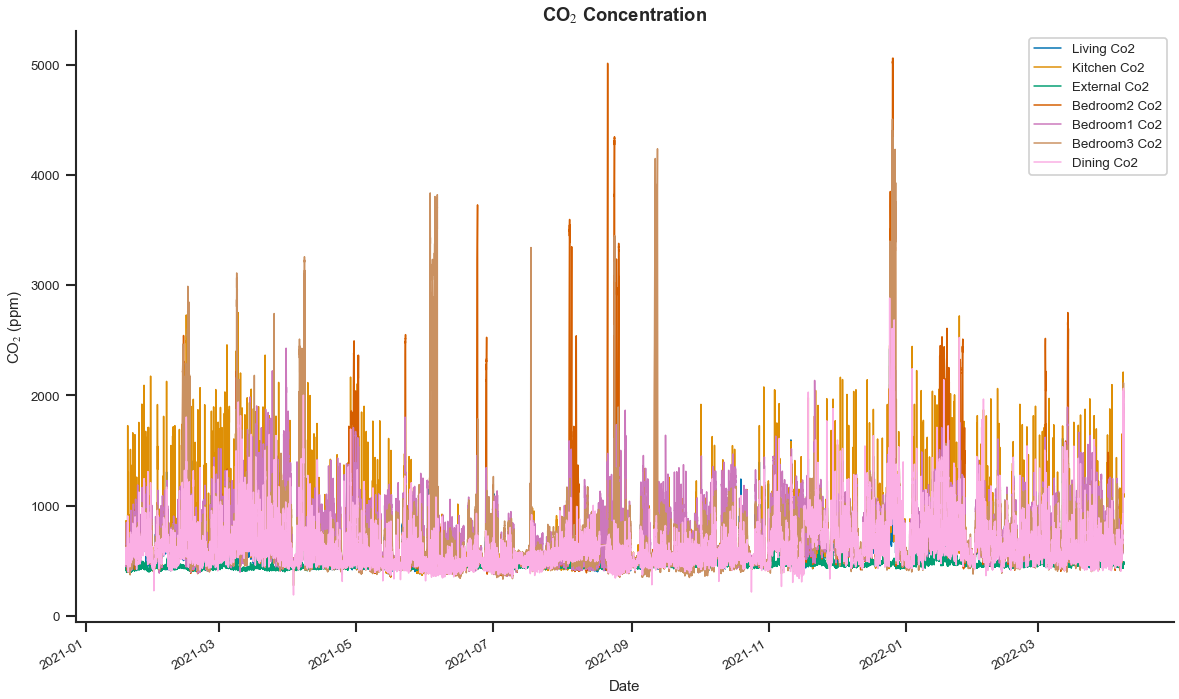

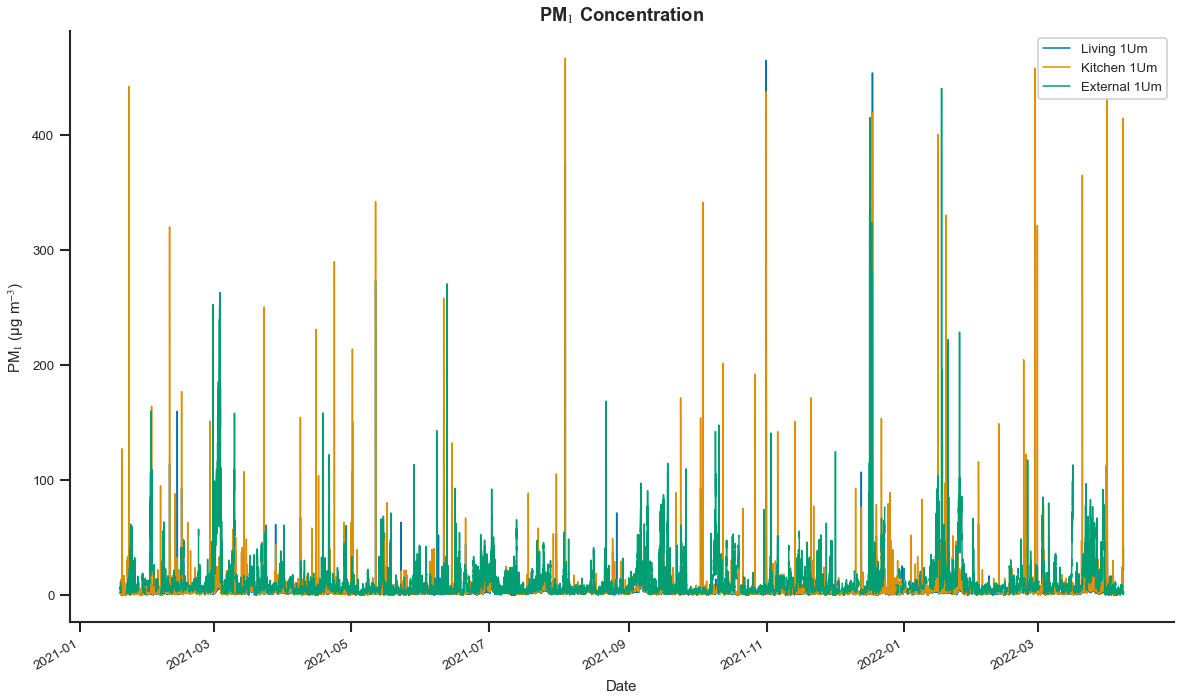

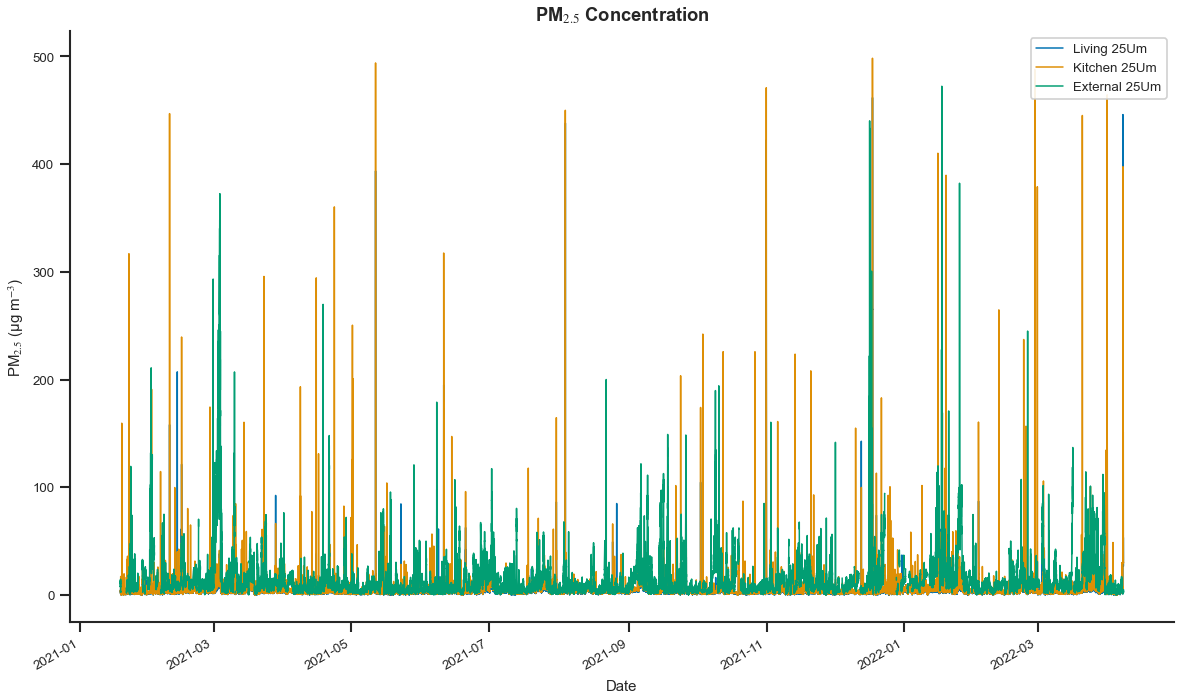

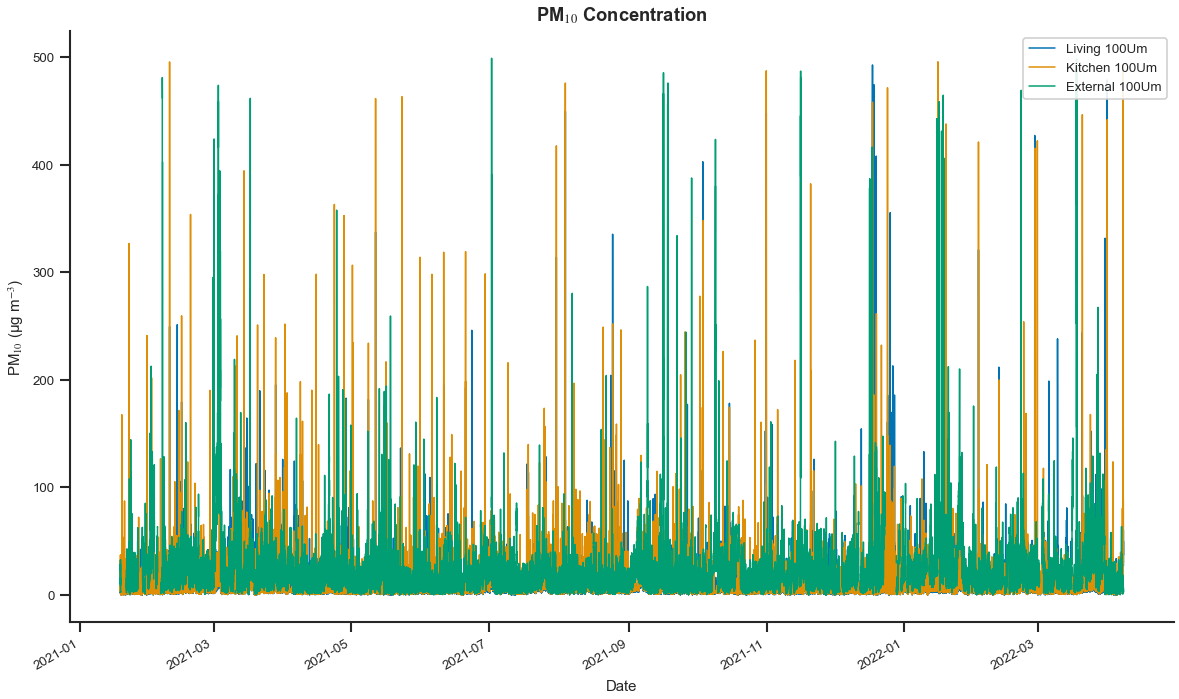

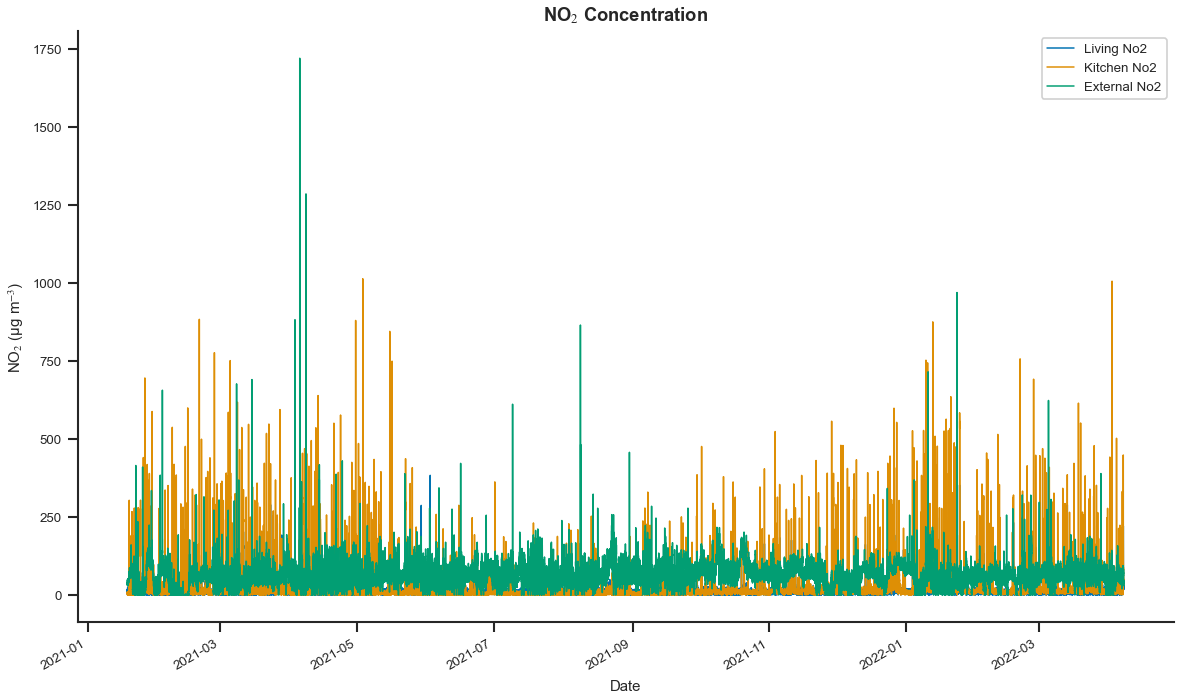

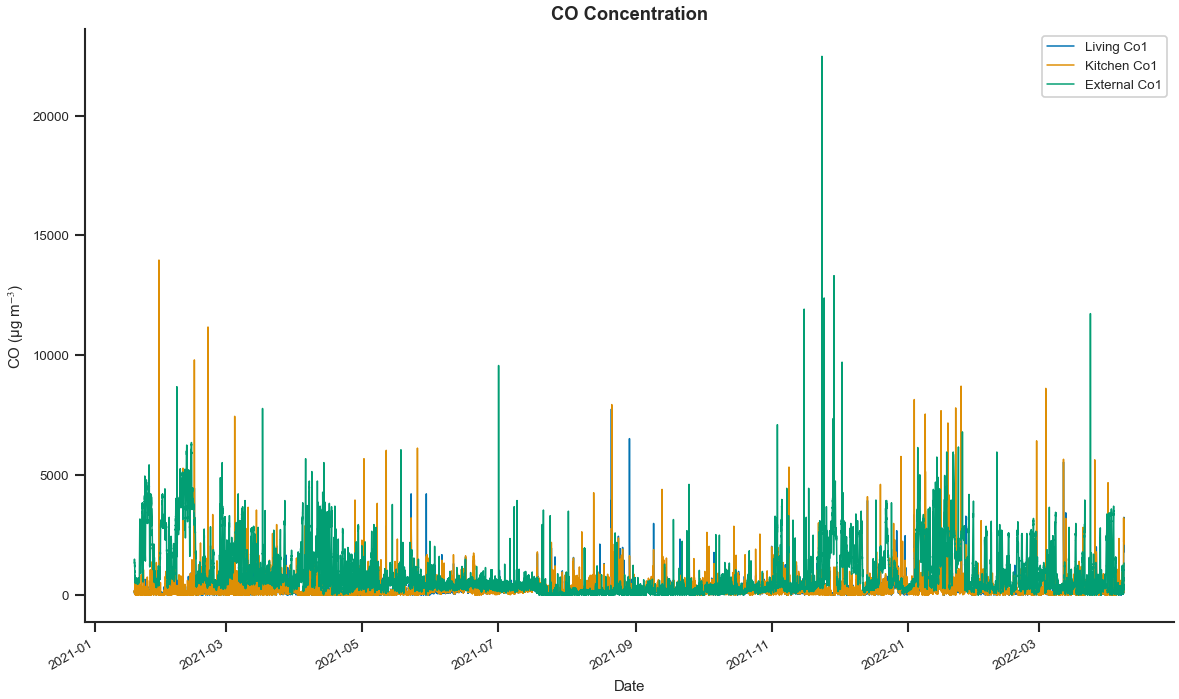

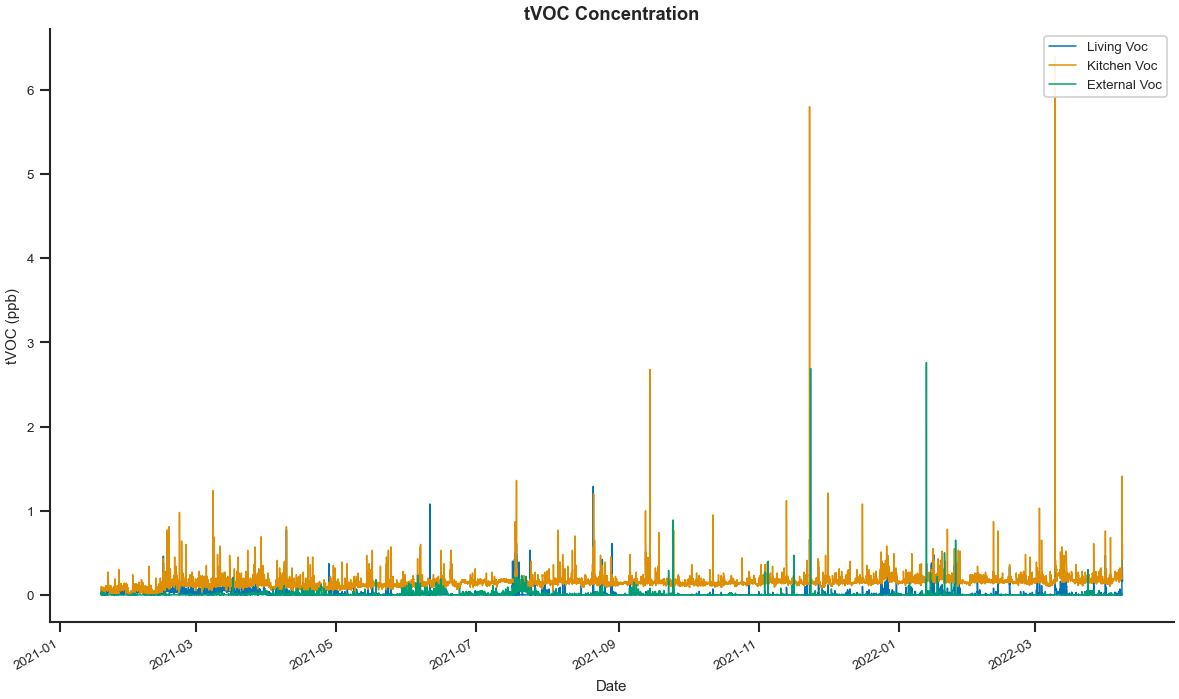

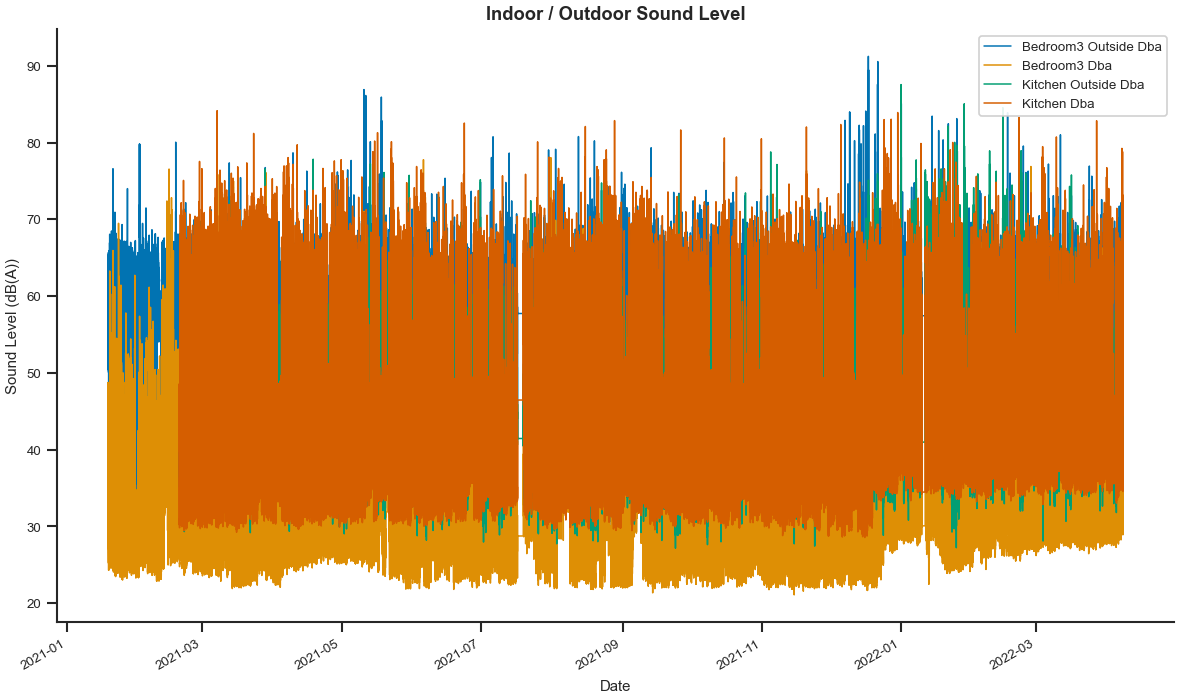

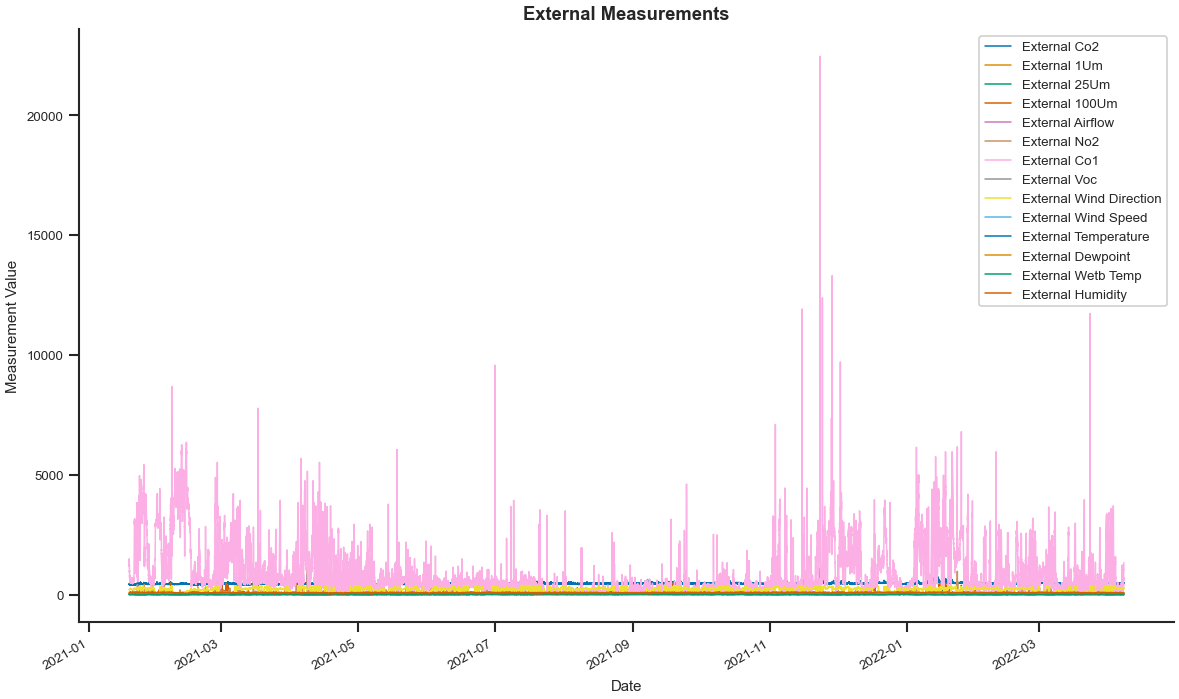

In [21]:
plot_grouped_variables(input_dataframe=p2, input_save=True, save_path="../data/p2_oxford_semi/plots/", figsize=(10, 6), dpi=300)

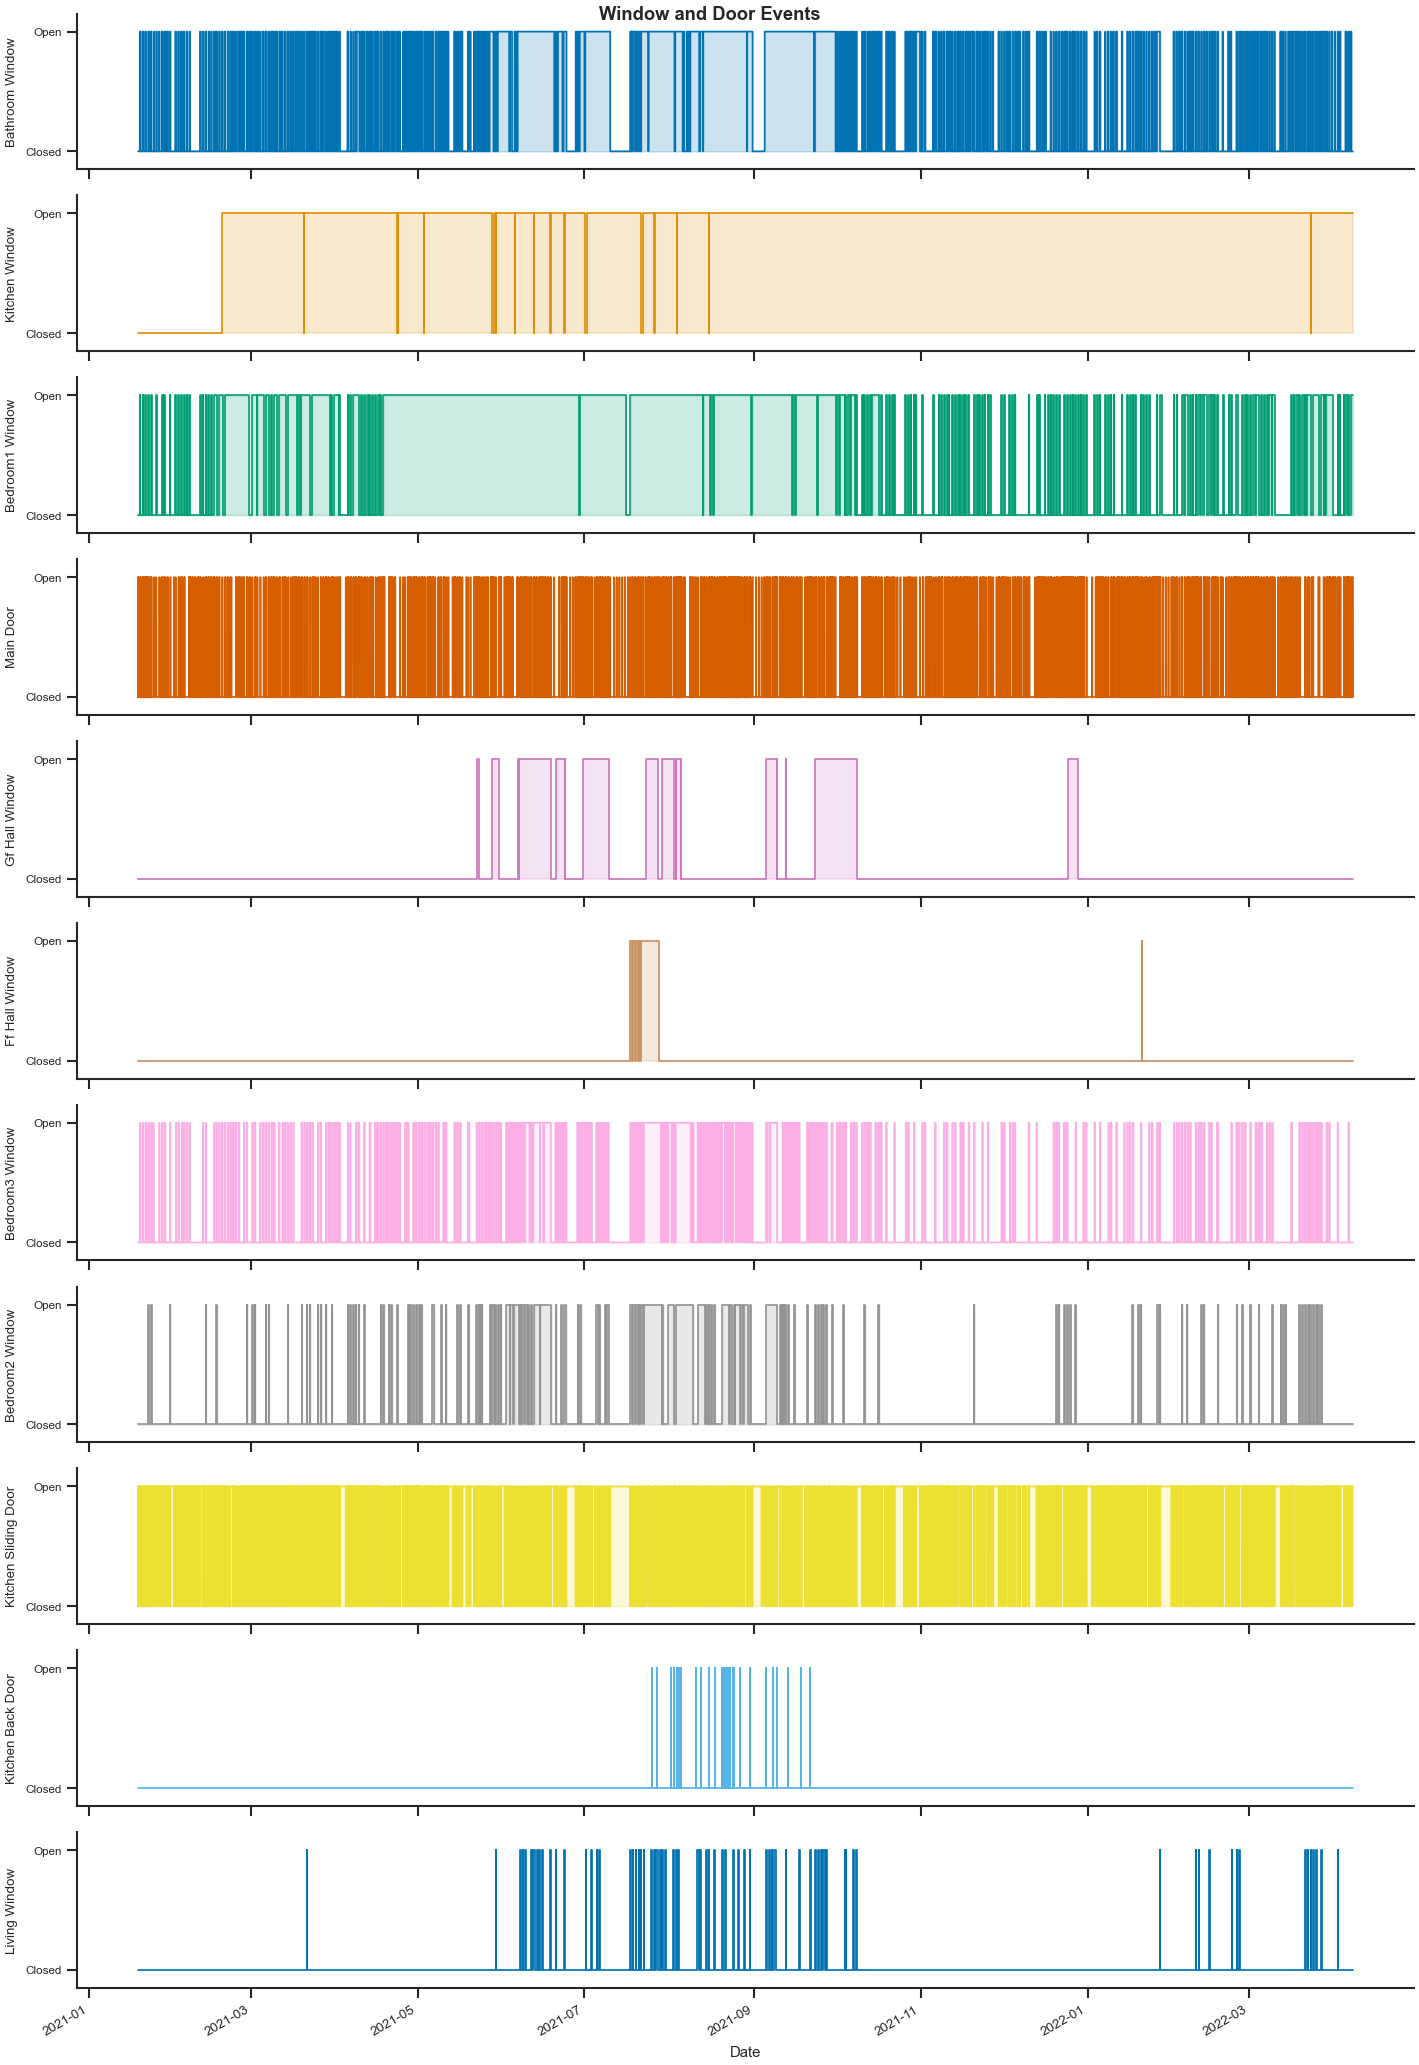

In [22]:
plot_event_timeseries(input_event_dict=p2_event_dict,
                      input_start_date=monitoring_start_date,
                      input_end_date=monitoring_end_date,
                      input_save=True,
                      save_path='../data/p2_oxford_semi/plots/')

## Summary statistics

In [23]:
p2_continuous_stats, p2_event_stats = summary_statistics(
    input_dataframe=p2,
    input_rooms_and_variables=p2_rooms_and_variables,
    input_event_dict=p2_event_dict,
    input_rooms_and_events=p2_rooms_and_events
)

# Print the number of days of data collected
num_days = (p2.index[-1] - p2.index[0]).days
print(f"Number of days of data collected: {num_days} days")


====    Summary Statistics    ====

--- Continuous Variables ---

  bedroom3_temperature: n=127944, n_missing=0, mean=20.058, median=19.912
  bedroom3_humidity: n=127944, n_missing=0, mean=56.191, median=54.59
  bedroom3_co2: n=127944, n_missing=0, mean=723.907, median=645.0
  bedroom3_dba: n=127944, n_missing=0, mean=35.502, median=32.14
  kitchen_temperature: n=127944, n_missing=0, mean=19.253, median=19.2
  kitchen_humidity: n=127944, n_missing=0, mean=57.787, median=57.2
  kitchen_co2: n=127944, n_missing=0, mean=635.186, median=574.822
  kitchen_1um: n=127944, n_missing=0, mean=3.714, median=2.1
  kitchen_25um: n=127944, n_missing=0, mean=4.684, median=2.78
  kitchen_100um: n=127944, n_missing=0, mean=7.043, median=3.42
  kitchen_airflow: n=127944, n_missing=0, mean=3.537, median=3.52
  kitchen_no2: n=127944, n_missing=0, mean=20.215, median=9.371
  kitchen_co1: n=127944, n_missing=0, mean=249.284, median=162.988
  kitchen_voc: n=127944, n_missing=0, mean=0.149, median=0.14
  kit

## Save outputs

In [24]:
save_participant_outputs(
    n=2,
    df=p2,
    event_dict=p2_event_dict,
    rooms_and_variables=p2_rooms_and_variables,
    rooms_and_events=p2_rooms_and_events,
    rooms_list=p2_rooms_list,
    continuous_stats=p2_continuous_stats,
    event_stats=p2_event_stats,
    data_dir='../data/p2_oxford_semi')

p2 outputs saved to ../data/p2_oxford_semi/data_processed/p2_outputs.pkl
